# Intro

DeiT (data-efficient image transformers) are more efficiently trained transformers for image classification, requiring far less data and far less computing resources compared to the original ViT models.

In this notebook, we implement a transfer learning workflow using a pre-trained Vision Transformer (DeiT). The primary objective is to evaluate the model's performance on our target dataset while utilizing Attention Rollout to interpret and visualize the model's decision-making process.

### Imports

In [49]:
import timm
import torch.nn as nn
import os
import torch
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import classification_report
import math
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as patches


### Load kedro

In [2]:
os.chdir("../../")

%load_ext kedro.ipython

[05/03/26 14:53:47] INFO     Using                                                                  ]8;id=413209;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=812416;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\framework\project\__init__.py#269\269]8;;\
                             'c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-pac                
                             kages\kedro\framework\project\rich_logging.yml' as logging                            
                             configuration.                                                                        

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=396875;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=844443;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#64\64]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=382228;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=335908;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#66\66]8;;\

                    INFO     Resolved project path as:                                              ]8;id=44968;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=480943;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#181\181]8;;\
                             c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\cxr-training-pipeli                
                             ne.                                                                                   
                             To set a different path, run '%reload_kedro <project_root>'                           

[05/03/26 14:53:52] WARNING  c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-pack ]8;id=346144;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=94419;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             ages\requests\__init__.py:113: RequestsDependencyWarning: urllib3                     
                             (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't                   
                             match a supported version!                                                            
                               warnings.warn(                                                                      
                                                                                                                   

...

[05/03/26 14:54:03] WARNING  c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-pack ]8;id=905921;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=36658;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             ages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning:                   
                             The filesystem tracking backend (e.g., './mlruns') is deprecated as of                
                             February 2026. Consider transitioning to a database backend (e.g.,                    
                             'sqlite:///mlflow.db') to take advantage of the latest MLflow                         
                             features. See                                                                         
                             https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store                   
                             for migration guidance.                                                               
                               return FileStore(store_uri, store_uri)                                              
                                                                                                                   

[05/03/26 14:54:33] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=991092;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=436172;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro_telemetry\plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[05/03/26 14:54:34] INFO     Kedro project cxr-training-pipeline                                    ]8;id=373786;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=524656;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#147\147]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=628890;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=250758;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#148\148]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=591440;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=951005;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#154\154]8;;\

### Load data

In [3]:
train_val = catalog.load("xray_train_val")
test = catalog.load("xray_test")

[05/03/26 14:55:24] INFO     Loading data from xray_train_val (CSVDataset)...                  ]8;id=443109;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=842457;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

                    INFO     Loading data from xray_test (CSVDataset)...                       ]8;id=975868;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=88147;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

In [4]:
train_val.head()

,image_index,finding_labels,patient_age,patient_sex,view_position,Infiltration,Effusion,Atelectasis,Nodule,Mass,Pneumothorax,Consolidation,Pleural_Thickening,Cardiomegaly,Emphysema,Edema,Fibrosis,Pneumonia,Hernia
0,00000001_000.png,Cardiomegaly,57,M,PA,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,58,M,PA,0,0,0,0,0,0,0,0,1,1,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,58,M,PA,0,1,0,0,0,0,0,0,1,0,0,0,0,0
3,00000002_000.png,No Finding,80,M,PA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,00000004_000.png,Mass|Nodule,82,M,AP,0,0,0,1,1,0,0,0,0,0,0,0,0,0


In [5]:
pathologies = ["Infiltration", "Effusion", "Atelectasis", "Nodule", "Mass", "Pneumothorax", "Consolidation", "Pleural_Thickening", "Cardiomegaly", "Emphysema", "Edema", "Fibrosis", "Pneumonia", "Hernia"]

print(len(pathologies))

14


In [6]:
def make_vector(row):
    """Create a binary pathology vector from a row."""
    vector = [0] * len(pathologies)
    for i, pathology in enumerate(pathologies):
        if row.get(pathology) == 1:
            vector[i] = 1
    return vector

In [7]:
train_val['pathology_vector'] = train_val.apply(make_vector, axis=1)
test['pathology_vector'] = test.apply(make_vector, axis=1)

In [8]:
train_val.head()

,image_index,finding_labels,patient_age,patient_sex,view_position,Infiltration,Effusion,Atelectasis,Nodule,Mass,Pneumothorax,Consolidation,Pleural_Thickening,Cardiomegaly,Emphysema,Edema,Fibrosis,Pneumonia,Hernia,pathology_vector
0,00000001_000.png,Cardiomegaly,57,M,PA,0,0,0,0,0,0,0,0,1,0,0,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]"
1,00000001_001.png,Cardiomegaly|Emphysema,58,M,PA,0,0,0,0,0,0,0,0,1,1,0,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0]"
2,00000001_002.png,Cardiomegaly|Effusion,58,M,PA,0,1,0,0,0,0,0,0,1,0,0,0,0,0,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]"
3,00000002_000.png,No Finding,80,M,PA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
4,00000004_000.png,Mass|Nodule,82,M,AP,0,0,0,1,1,0,0,0,0,0,0,0,0,0,"[0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


In [9]:
test.head()

,image_index,finding_labels,patient_age,patient_sex,view_position,Infiltration,Effusion,Atelectasis,Nodule,Mass,Pneumothorax,Consolidation,Pleural_Thickening,Cardiomegaly,Emphysema,Edema,Fibrosis,Pneumonia,Hernia,pathology_vector
0,00000003_001.png,Hernia,74,F,PA,0,0,0,0,0,0,0,0,0,0,0,0,0,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
1,00000003_002.png,Hernia,75,F,PA,0,0,0,0,0,0,0,0,0,0,0,0,0,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
2,00000003_003.png,Hernia|Infiltration,76,F,PA,1,0,0,0,0,0,0,0,0,0,0,0,0,1,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
3,00000003_004.png,Hernia,77,F,PA,0,0,0,0,0,0,0,0,0,0,0,0,0,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
4,00000003_005.png,Hernia,78,F,PA,0,0,0,0,0,0,0,0,0,0,0,0,0,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"


### Model and training

In [19]:
def create_model(pathologies: list[str]) -> nn.Module:
    """Create a model using timm."""
    model = timm.create_model(
    "deit_tiny_patch16_224", pretrained=True,
    num_classes=len(pathologies),
)

    return model

def load_model(path: str) -> nn.Module:
    """Load a model from a file."""
    model = create_model(pathologies)
    model.load_state_dict(torch.load(path, weights_only=True))
    return model

In [11]:
model = create_model(pathologies)


In [12]:
model


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)

In [20]:
loaded_model = load_model("deit_tiny_chest_xray.pth")

In [22]:
loaded_model == model

False

In [24]:
def set_seed(seed: int):
    """Set random seeds for reproducibility."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def split_data(train_val: pd.DataFrame, test_size: float = 0.25, random_state: int = 42):
    """Split the data into training and validation sets."""

    train_df, val_df = train_test_split(train_val, test_size=test_size, random_state=random_state)
    return train_df, val_df

def reduce_no_finding_in_data(train_df: pd.DataFrame, pathologies: list[str], ratio: float = 0.25, random_state: int = 42):
    """Reduce the number of all-zero "No Finding" samples in the training split."""
    no_finding_mask = train_df[pathologies].sum(axis=1) == 0
    finding_df = train_df.loc[~no_finding_mask]
    no_finding_df = train_df.loc[no_finding_mask]

    max_no_finding = int(len(finding_df) * ratio)

    if len(no_finding_df) > max_no_finding:
        no_finding_df = no_finding_df.sample(n=max_no_finding, random_state=random_state)

    reduced_train_df = (
        pd.concat([finding_df, no_finding_df], axis=0)
          .sample(frac=1.0, random_state=random_state)
          .reset_index(drop=True)
    )

    return reduced_train_df

def calculate_pos_weight(train_df: pd.DataFrame, pathologies: list[str]) -> torch.Tensor:
    """Calculate pos_weight for BCE loss."""
    pos_counts = train_df[pathologies].sum(axis=0)  # positive samples per class
    neg_counts = len(train_df) - pos_counts      # negative samples per class

    pos_weight = torch.tensor((neg_counts / (pos_counts + 1e-8)).to_numpy(), dtype=torch.float32)

    return pos_weight

set_seed(42)

train_df, val_df = split_data(train_val, test_size=0.25, random_state=42)

no_findings_before = (train_df[pathologies].sum(axis=1) == 0).sum()
print(f"Train split before downsampling: {len(train_df)}")
print(f"  finding cases: {len(train_df) - no_findings_before}")
print(f"  no_finding cases: {no_findings_before}")

train_df = reduce_no_finding_in_data(train_df, pathologies, ratio=0.25, random_state=42)

no_findings_after = (train_df[pathologies].sum(axis=1) == 0).sum()
print(f"Train split after downsampling: {len(train_df)}")
print(f"  finding cases: {len(train_df) - no_findings_after}")
print(f"  no_finding cases: {no_findings_after}")

pos_weight = calculate_pos_weight(train_df, pathologies)

print("BCE pos_weight:")
for pathology, weight in zip(pathologies, pos_weight):
    print(f"  {pathology}: {weight.item():.2f}")

Train split before downsampling: 64893
  finding cases: 26982
  no_finding cases: 37911
Train split after downsampling: 33727
  finding cases: 26982
  no_finding cases: 6745
BCE pos_weight:
  Infiltration: 2.26
  Effusion: 4.20
  Atelectasis: 4.49
  Nodule: 8.46
  Mass: 10.13
  Pneumothorax: 16.14
  Consolidation: 14.97
  Pleural_Thickening: 19.35
  Cardiomegaly: 26.00
  Emphysema: 30.79
  Edema: 31.46
  Fibrosis: 34.96
  Pneumonia: 49.57
  Hernia: 326.45


### Custom Dataset for DeiT

In [26]:
class PathologyDataset(Dataset):
    """Custom dataset for loading chest X-rays with pathology labels."""

    def __init__(self, dataframe, image_dir="data/01_raw/images", transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform or transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Grayscale(num_output_channels=3),  # Convert to 3 channels for DeiT
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_index = row['image_index']
        image_path = os.path.join(self.image_dir, image_index)

        # Load image
        image = Image.open(image_path)
        if image.mode != 'L':
            image = image.convert('L')
        image = self.transform(image)

        # Load pathology vector
        pathology_vector = torch.tensor(row['pathology_vector'], dtype=torch.float32)

        return {
            'image': image,
            'labels': pathology_vector,
            'image_index': image_index
        }

In [27]:
train_dataset = PathologyDataset(train_df, image_dir="data/01_raw/images")
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)

val_dataset = PathologyDataset(val_df, image_dir="data/01_raw/images")
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

test_dataset = PathologyDataset(test, image_dir="data/01_raw/images")
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 33727
Validation dataset size: 21631
Test dataset size: 25596


In [29]:

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    num_batches = 0

    for batch in tqdm(dataloader, desc="Train"):
        images = batch['image'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / max(1, num_batches)

def evaluate_epoch(model, dataloader, criterion, device, pathologies=None):
    model.eval()
    total_loss = 0.0
    num_batches = 0
    all_predicted = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluate"):
            images = batch['image'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            num_batches += 1

            preds = (torch.sigmoid(outputs) > 0.5).float()
            all_predicted.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / max(1, num_batches)

    report = None
    if pathologies is not None:
        try:
            report = classification_report(
                np.array(all_labels),
                np.array(all_predicted),
                target_names=pathologies,
                zero_division=0
            )
        except Exception as e:
            report = f"Could not produce classification report: {e}"

    return avg_loss, report


def run_training_pipeline(model, train_loader, val_loader, test_loader,
                          criterion, optimizer, num_epochs, device, save_path, pathologies):

    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        print(f"\n--- Epoch {epoch+1}/{num_epochs} ---")

        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        print(f"Train Loss: {train_loss:.4f}")

        val_loss, val_report = evaluate_epoch(model, val_loader, criterion, device, pathologies)
        print(f"Val Loss: {val_loss:.4f}")

        if val_report:
            print("Validation classification report:\n", val_report)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(f"✨ New best model saved with val loss: {best_val_loss:.4f}")

    print("\n--- Testing on test set ---")
    test_loss, test_report = evaluate_epoch(model, test_loader, criterion, device, pathologies)
    print(f"Test Loss: {test_loss:.4f}")

    if test_report:
        print("Test classification report:\n", test_report)

    print("Training and evaluation complete!")

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_model(pathologies).to(device)

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

model_save_path = r"test_pipeline.pth"

run_training_pipeline(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=1,
    device=device,
    save_path=model_save_path,
    pathologies=pathologies
)


--- Epoch 1/1 ---


Train: 100%|██████████| 2108/2108 [17:15<00:00,  2.04it/s]


Train Loss: 1.2434


Evaluate: 100%|██████████| 1352/1352 [08:34<00:00,  2.63it/s]


Val Loss: 0.9506
Validation classification report:
                     precision    recall  f1-score   support

      Infiltration       0.19      0.78      0.30      3450
          Effusion       0.19      0.63      0.29      2168
       Atelectasis       0.15      0.69      0.24      2133
            Nodule       0.06      0.60      0.10      1142
              Mass       0.06      0.47      0.10      1005
      Pneumothorax       0.05      0.57      0.10       669
     Consolidation       0.06      0.74      0.11       740
Pleural_Thickening       0.06      0.07      0.06       585
      Cardiomegaly       0.05      0.23      0.09       458
         Emphysema       0.02      0.90      0.03       362
             Edema       0.04      0.86      0.07       339
          Fibrosis       0.03      0.21      0.05       313
         Pneumonia       0.01      0.78      0.02       209
            Hernia       0.00      0.76      0.00        38

         micro avg       0.07      0.63      0

Evaluate: 100%|██████████| 1600/1600 [10:22<00:00,  2.57it/s]

Test Loss: 1.2358
Test classification report:
                     precision    recall  f1-score   support

      Infiltration       0.26      0.92      0.40      6112
          Effusion       0.24      0.79      0.37      4658
       Atelectasis       0.15      0.78      0.25      3279
            Nodule       0.08      0.44      0.14      1623
              Mass       0.10      0.42      0.16      1748
      Pneumothorax       0.18      0.58      0.27      2665
     Consolidation       0.09      0.87      0.17      1815
Pleural_Thickening       0.07      0.05      0.06      1143
      Cardiomegaly       0.07      0.24      0.10      1069
         Emphysema       0.05      0.84      0.09      1093
             Edema       0.06      0.93      0.10       925
          Fibrosis       0.04      0.20      0.06       435
         Pneumonia       0.02      0.93      0.04       555
            Hernia       0.01      0.72      0.01        86

         micro avg       0.11      0.70      0.20  

### Predictions

In [41]:
def predict_on_loader(model, dataloader, device):
    model.eval()

    all_predicted = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Predicting"):
            images = batch['image'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(images)
            predicted = (torch.sigmoid(outputs) > 0.5).float()

            all_predicted.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_predicted), np.array(all_labels)

def generate_classification_report(all_predicted: np.ndarray, all_labels: np.ndarray, pathologies: list[str]):
    try:
        report = classification_report(
            all_labels,
            all_predicted,
            target_names=pathologies,
            zero_division=0
        )
        return report
    except Exception as e:
        return f"Could not produce classification report: {e}"

def test_model(model, test_loader, device, pathologies):
    all_predicted, all_labels = predict_on_loader(model, test_loader, device)
    report = generate_classification_report(all_predicted, all_labels, pathologies)
    print("Test classification report:\n", report)

I have 3 models that i trained. Each of them was trained on the same dataset with 224x224 images:
- 6 epochs
- 15 epochs best val_loss
- 15 epoch last

In [46]:
first_6_epochs_model = load_model("data/06_models/deit_models/deit_tiny_chest_xray.pth").to(device)
second_15_epochs_best_model = load_model("data/06_models/deit_models/deit_tiny_chest_xray_bigger_epochs.pth").to(device)
third_15_epochs_model = load_model("data/06_models/deit_models/deit_tiny_chest_xray_bigger_epochs_last_version.pth").to(device)

In [44]:
print("Evaluating first 6 epochs model:")
test_model(first_6_epochs_model, test_loader, device, pathologies)

print("\nEvaluating second 15 epochs best model:")
test_model(second_15_epochs_best_model, test_loader, device, pathologies)

print("\nEvaluating third 15 epochs model:")
test_model(third_15_epochs_model, test_loader, device, pathologies)


Evaluating first 6 epochs model:


Predicting: 100%|██████████| 1600/1600 [10:28<00:00,  2.55it/s]


Test classification report:
                     precision    recall  f1-score   support

      Infiltration       0.30      0.65      0.41      6112
          Effusion       0.28      0.74      0.41      4658
       Atelectasis       0.20      0.58      0.30      3279
            Nodule       0.09      0.52      0.15      1623
              Mass       0.09      0.66      0.16      1748
      Pneumothorax       0.16      0.79      0.26      2665
     Consolidation       0.11      0.75      0.19      1815
Pleural_Thickening       0.07      0.75      0.12      1143
      Cardiomegaly       0.09      0.70      0.16      1069
         Emphysema       0.06      0.78      0.11      1093
             Edema       0.10      0.68      0.17       925
          Fibrosis       0.03      0.74      0.06       435
         Pneumonia       0.03      0.72      0.06       555
            Hernia       0.01      0.72      0.01        86

         micro avg       0.12      0.68      0.20     27206
         

Predicting: 100%|██████████| 1600/1600 [11:04<00:00,  2.41it/s]


Test classification report:
                     precision    recall  f1-score   support

      Infiltration       0.30      0.70      0.42      6112
          Effusion       0.31      0.69      0.43      4658
       Atelectasis       0.20      0.65      0.30      3279
            Nodule       0.09      0.59      0.16      1623
              Mass       0.11      0.59      0.19      1748
      Pneumothorax       0.18      0.81      0.30      2665
     Consolidation       0.11      0.69      0.20      1815
Pleural_Thickening       0.08      0.57      0.15      1143
      Cardiomegaly       0.10      0.72      0.18      1069
         Emphysema       0.07      0.68      0.13      1093
             Edema       0.08      0.84      0.14       925
          Fibrosis       0.04      0.40      0.08       435
         Pneumonia       0.04      0.53      0.07       555
            Hernia       0.02      0.12      0.03        86

         micro avg       0.15      0.68      0.24     27206
         

Predicting: 100%|██████████| 1600/1600 [11:20<00:00,  2.35it/s]

Test classification report:
                     precision    recall  f1-score   support

      Infiltration       0.32      0.65      0.43      6112
          Effusion       0.30      0.72      0.42      4658
       Atelectasis       0.20      0.60      0.30      3279
            Nodule       0.09      0.50      0.15      1623
              Mass       0.10      0.60      0.18      1748
      Pneumothorax       0.22      0.43      0.29      2665
     Consolidation       0.11      0.58      0.18      1815
Pleural_Thickening       0.08      0.41      0.14      1143
      Cardiomegaly       0.18      0.44      0.25      1069
         Emphysema       0.10      0.31      0.15      1093
             Edema       0.09      0.53      0.16       925
          Fibrosis       0.04      0.33      0.07       435
         Pneumonia       0.04      0.16      0.06       555
            Hernia       0.03      0.10      0.05        86

         micro avg       0.17      0.57      0.26     27206
         

### Grad-CAM / Attention Rollout on DEIT

In [47]:
bbox = catalog.load("cxr8_bbox")

[05/03/26 16:52:32] INFO     Loading data from cxr8_bbox (CSVDataset)...                       ]8;id=749960;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=464559;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

In [48]:
bbox

,image_index,finding_label,x,y,w,h
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695
...,...,...,...,...,...,...
979,00029464_015.png,Atelectasis,198.940451,352.900747,615.537778,323.128889
980,00025769_001.png,Atelectasis,701.838229,572.491858,103.537778,63.715556
981,00016837_002.png,Atelectasis,140.913785,658.962969,271.928889,94.435556
982,00020124_003.png,Atelectasis,175.047118,580.456302,244.622222,103.537778


In [94]:
IDX = 444

In [95]:
image_index = bbox['image_index'].iloc[IDX]

In [69]:
def get_attention_hook(attn_maps):
    """
    Creates a hook function that captures and saves attention weights from the attention module.
    """
    def _hook(module, input, output):
        x = input[0]  # (B, N, C)
        B, N, C = x.shape
        qkv = module.qkv(x)  # (B, N, 3*C)

        # Determine number of attention heads
        num_heads = getattr(module, "num_heads", None) or getattr(module, "num_attn_heads", None) or 3
        head_dim = C // num_heads

        qkv = qkv.reshape(B, N, 3, num_heads, head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # each: (B, num_heads, N, head_dim)

        attn = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(head_dim))
        attn = torch.softmax(attn, dim=-1)  # (B, num_heads, N, N)
        attn_maps.append(attn.detach().cpu())

    return _hook


def compute_attention_rollout(attn_maps):
    """
    Computes attention rollout from a list of attention maps.
    """
    attn_stack = [a[0].mean(0).numpy() for a in attn_maps]  # average heads, take batch 0
    num_tokens = attn_stack[0].shape[0]

    rollout = np.eye(num_tokens)
    for a in attn_stack:
        a_aug = a + np.eye(num_tokens)
        a_aug = a_aug / a_aug.sum(axis=-1, keepdims=True)
        rollout = a_aug @ rollout

    return rollout


def process_attention_map(rollout):
    """
    Extracts the attention mask from the class token and reshapes it to a spatial patch grid.
    """
    mask = rollout[0, 1:]  # shape (num_patches,)
    patch_size = int(math.sqrt(mask.shape[0]))
    cam = mask.reshape(patch_size, patch_size)

    # Min-max normalization
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam


def generate_overlay(orig_img, cam):
    """
    Creates the overlay image from the original image and the upscaled CAM.
    """
    cam_img = Image.fromarray(np.uint8(cm.jet(cam) * 255)).resize((224, 224), resample=Image.BILINEAR)
    cam_arr = np.array(cam_img)[..., :3]  # RGBA to RGB

    orig_arr = np.array(orig_img)
    overlay = (0.6 * orig_arr.astype(float) + 0.4 * cam_arr.astype(float)).astype(np.uint8)

    return cam, overlay


def plot_attention_rollout(model, img_path, bbox_row=None):
    """
    Extracts attention maps, processes them, and plots the results including bounding box overlays.

    Parameters:
    -----------
    model : torch.nn.Module
        The model to use for attention extraction
    img_path : str
        Path to the image
    bbox_row : pd.Series, optional
        Series containing x, y, w, h coordinates for bounding box
    """
    model.eval()

    device = next(model.parameters()).device

    orig_img = Image.open(img_path).convert("RGB")
    orig_img = orig_img.resize((224, 224))

    img_tensor = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),  # Convert to 3 channels for DeiT
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])(orig_img).unsqueeze(0).to(device)

    attn_maps = []
    handles = []
    hook_fn = get_attention_hook(attn_maps)

    for blk in model.blocks:
        handles.append(blk.attn.register_forward_hook(hook_fn))

    _ = model(img_tensor)

    for h in handles:
        h.remove()

    rollout = compute_attention_rollout(attn_maps)
    cam = process_attention_map(rollout)
    cam_normalized, overlay = generate_overlay(orig_img, cam)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 3, 1)
    plt.title("Original")
    plt.axis("off")
    plt.imshow(np.array(orig_img))

    plt.subplot(1, 3, 2)
    plt.title("Attention rollout (upsampled)")
    plt.axis("off")
    plt.imshow(cam, cmap="jet")

    plt.subplot(1, 3, 3)
    plt.title("Overlay")
    plt.axis("off")
    plt.imshow(overlay)

    # Add bounding box if provided
    if bbox_row is not None:
        try:
            x, y, w, h = bbox_row[["x", "y", "w", "h"]].astype(float)

            scale_factor = orig_img.size[0] / 1024
            x_min_scaled = int(round(x * scale_factor))
            y_min_scaled = int(round(y * scale_factor))
            x_max_scaled = int(round((x + w) * scale_factor))
            y_max_scaled = int(round((y + h) * scale_factor))

            rect = patches.Rectangle(
                (x_min_scaled, y_min_scaled),
                x_max_scaled - x_min_scaled,
                y_max_scaled - y_min_scaled,
                linewidth=2,
                edgecolor='cyan',
                facecolor='none'
            )
            ax = plt.subplot(1, 3, 3)
            ax.add_patch(rect)
        except Exception as e:
            print(f"Could not add bounding box: {e}")

    plt.tight_layout()
    plt.show()


In [52]:
bbox.head()

,image_index,finding_label,x,y,w,h
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695


In [71]:
def get_random_row(df: pd.DataFrame):
    """Get a random image path and its corresponding bounding box."""
    random_row = df.sample(n=1).iloc[0]

    return random_row

In [141]:
random_row = get_random_row(bbox)

image_path = os.path.join("data/01_raw/images", random_row['image_index'])


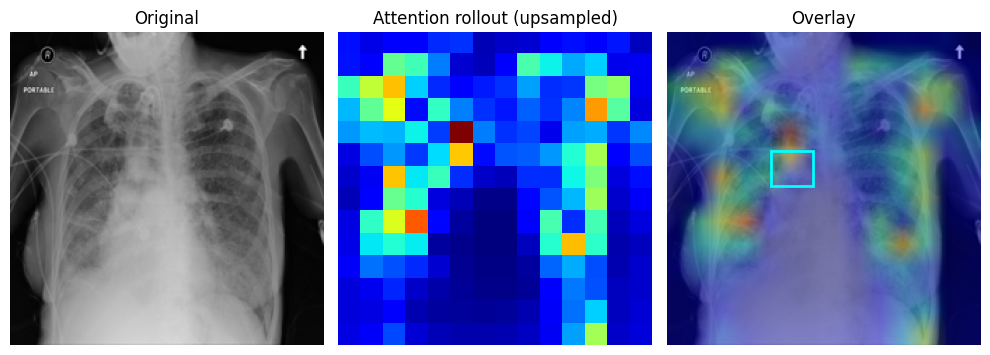

In [142]:
plot_attention_rollout(
    model=third_15_epochs_model,
    img_path=image_path,
    bbox_row=random_row
)


In [153]:
def calculate_iou_bbox(attention_mask, bbox_row, threshold=None, top_percent=0.2, return_masks=False):
    H, W = attention_mask.shape
    x, y, w, h = bbox_row[["x", "y", "w", "h"]].astype(float)

    scale = H / 1024.0
    x1 = int(round(x * scale)); y1 = int(round(y * scale))
    x2 = int(round((x + w) * scale)); y2 = int(round((y + h) * scale))

    x1, x2 = np.clip([x1, x2], 0, W)
    y1, y2 = np.clip([y1, y2], 0, H)

    bbox_mask = np.zeros((H, W), dtype=bool)
    if x1 < x2 and y1 < y2:
        bbox_mask[y1:y2, x1:x2] = True

    if threshold is None:
        k = max(1, int(np.prod(attention_mask.shape) * top_percent))
        thresh = np.sort(attention_mask.ravel())[-k]
    else:
        thresh = float(threshold)

    attention_binary = attention_mask >= thresh

    inter = np.logical_and(attention_binary, bbox_mask).sum()
    union = np.logical_or(attention_binary, bbox_mask).sum()

    iou = float(inter) / (float(union) + 1e-8) if union > 0 else 0.0

    if return_masks:
        return iou, attention_binary, bbox_mask
    return iou



In [155]:
def calculate_iou_for_image(model, img_path, bbox_row, device):
    model.eval()

    orig_img = Image.open(img_path).convert("RGB").resize((224, 224))

    img_tensor = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])(orig_img).unsqueeze(0).to(device)

    attn_maps = []
    handles = []
    hook_fn = get_attention_hook(attn_maps)

    for blk in model.blocks:
        handles.append(blk.attn.register_forward_hook(hook_fn))

    with torch.no_grad():
        _ = model(img_tensor)

    for h in handles:
        h.remove()

    rollout = compute_attention_rollout(attn_maps)
    cam = process_attention_map(rollout)

    iou = calculate_iou_bbox(cam, bbox_row)
    return iou, cam


random_row = get_random_row(bbox)
image_path = os.path.join("data/01_raw/images", random_row["image_index"])

iou, attention_mask = calculate_iou_for_image(
    model=third_15_epochs_model,
    img_path=image_path,
    bbox_row=random_row,
    device=device
)

print(f"IoU for image {random_row['image_index']}: {iou:.4f}")


IoU for image 00020113_030.png: 0.0513


In [156]:
def calculate_average_iou(model, bbox_df):
    ious = []

    for idx in range(len(bbox_df)):
        row = bbox_df.iloc[idx]
        image_path = os.path.join("data/01_raw/images", row['image_index'])

        iou, _ = calculate_iou_for_image(
            model=model,
            img_path=image_path,
            bbox_row=row,
            device=device
        )

        ious.append(iou)

    ious = np.array(ious)
    return ious

ious_first_6_epochs = calculate_average_iou(first_6_epochs_model, bbox)
print(f"Average IoU for first 6 epochs model: {np.nanmean(ious_first_6_epochs):.4f}")

ious_second_15_epochs = calculate_average_iou(second_15_epochs_best_model, bbox)
print(f"Average IoU for second 15 epochs best model: {np.nanmean(ious_second_15_epochs):.4f}")

ious_third_15_epochs = calculate_average_iou(third_15_epochs_model, bbox)
print(f"Average IoU for third 15 epochs model: {np.nanmean(ious_third_15_epochs):.4f}")

Average IoU for first 6 epochs model: 0.1060
Average IoU for second 15 epochs best model: 0.0668
Average IoU for third 15 epochs model: 0.0643
